# Phase 4: Advanced Behavioral Visualizations & HR Storytelling

## Objective
The goal of this notebook is to convert our machine learning insights and data structures into executive-ready visualizations. We will explore:
1. **Departmental Attrition Hotspots** using an annotated Heatmap.
2. **The Age vs. Income Risk Boundary** using a multi-variable Scatter Plot.
3. **Career Stagnation Timelines** using distribution Box Plots.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # This is the correct, standard library for styling

# 1. Load the raw dataset directly to reconstruct our baseline
file_path = r'D:\DA-project-02-HR Analytics\DA-project-02-HR-Analytics\data\WA_Fn-UseC_-HR-Employee-Attrition.csv'

try:
    df_raw = pd.read_csv(file_path)
    print("Raw dataset successfully loaded directly from source!")
except FileNotFoundError:
    df_raw = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# 2. Re-isolate Top Talent based on Phase 2/3 definitions (OR condition)
top_talent_condition = (df_raw['PerformanceRating'] == 4) | (df_raw['PercentSalaryHike'] >= 15)
df_talent = df_raw[top_talent_condition].copy()

# 3. Map target variable to numeric for calculation purposes
df_talent['Attrition_Numeric'] = df_talent['Attrition'].apply(lambda x: 1 if x == 'Yes' or x == 1 else 0)

print(f"\n✅ Setup Complete! Ready to generate executive visuals for {df_talent.shape[0]} top performers.")

Raw dataset successfully loaded directly from source!

✅ Setup Complete! Ready to generate executive visuals for 652 top performers.


## 1. Mapping Organization Hotspots (Department vs. Job Role)

To identify exactly where the "Brain Drain" is localized, we will look at the exact attrition rate across different roles and departments. This heatmap targets structural vulnerabilities.

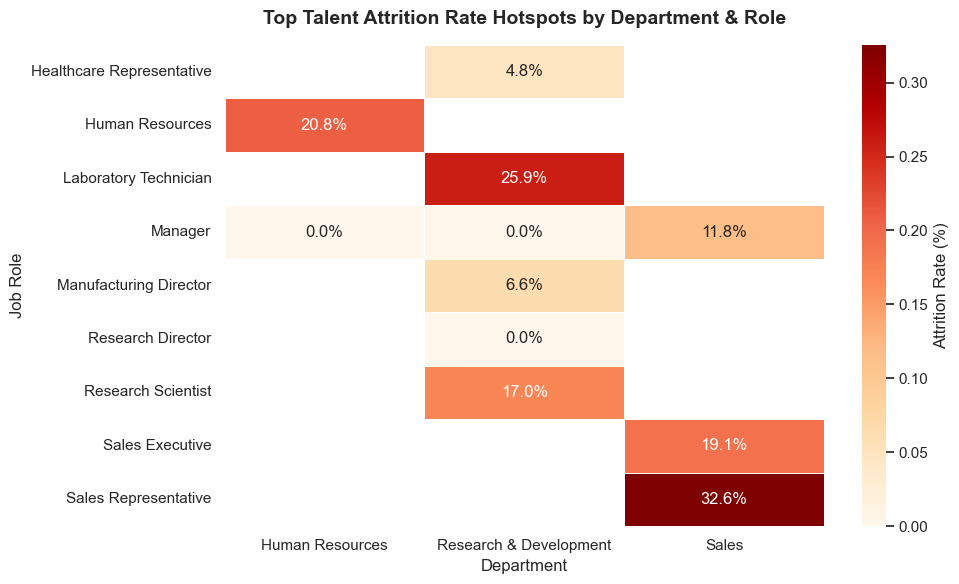

In [3]:
# Create Pivot Table for Attrition Rates
heatmap_data = df_talent.pivot_table(values='Attrition_Numeric', index='JobRole', columns='Department', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.set_theme(style="white")

# Plotting the Heatmap
ax = sns.heatmap(heatmap_data, annot=True, fmt=".1%", cmap="OrRd", linewidths=.5, cbar_kws={'label': 'Attrition Rate (%)'})

plt.title('Top Talent Attrition Rate Hotspots by Department & Role', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Job Role', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Risk Boundaries: Income vs. Age Distribution

Our machine learning model indicated that `Age` and `MonthlyIncome` carry massive structural weight. This scatter plot visually maps out the "Danger Zone" where top performers decide to leave the company.

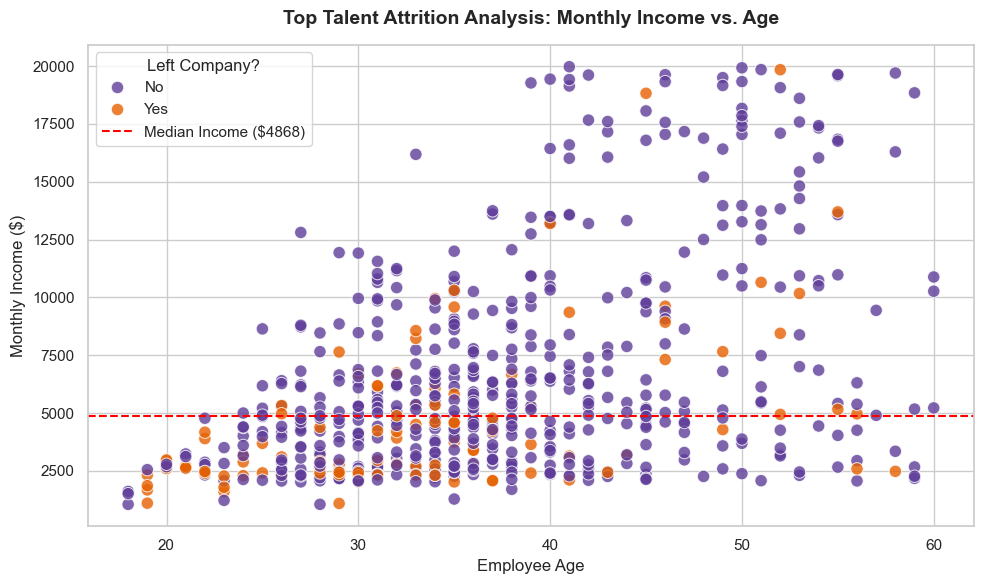

In [4]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create Scatter Plot split by Attrition Status
sns.scatterplot(data=df_talent, x='Age', y='MonthlyIncome', hue='Attrition', palette={'Yes': '#E66101', 'No': '#5E3C99'}, alpha=0.8, s=80)

# Add a median income line as an operational reference boundary
median_income = df_talent['MonthlyIncome'].median()
plt.axhline(median_income, color='red', linestyle='--', linewidth=1.5, label=f'Median Income (${int(median_income)})')

plt.title('Top Talent Attrition Analysis: Monthly Income vs. Age', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Employee Age', fontsize=12)
plt.ylabel('Monthly Income ($)', fontsize=12)
plt.legend(title='Left Company?', loc='upper left')
plt.tight_layout()
plt.show()

## 3. The Stagnation Trigger: Time Since Last Promotion

We will look at how long an employee has been sitting in their role without a promotion (`YearsSinceLastPromotion`) to identify the exact point where stagnation triggers a departure.

C:\Users\U s e r\AppData\Local\Temp\ipykernel_4040\868337246.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_talent, x='Attrition', y='YearsSinceLastPromotion', palette='Set3', width=0.5)


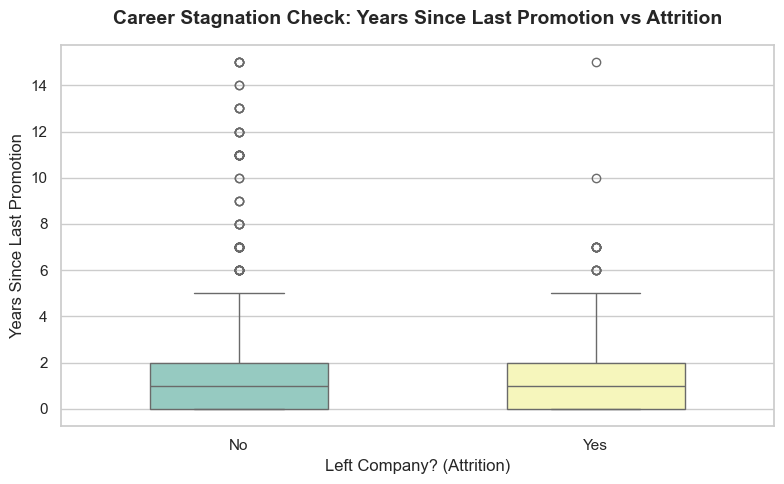

In [5]:
plt.figure(figsize=(8, 5))

# Create Box Plot to show distribution variance
sns.boxplot(data=df_talent, x='Attrition', y='YearsSinceLastPromotion', palette='Set3', width=0.5)

plt.title('Career Stagnation Check: Years Since Last Promotion vs Attrition', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Left Company? (Attrition)', fontsize=12)
plt.ylabel('Years Since Last Promotion', fontsize=12)
plt.tight_layout()
plt.show()